In [ ]:
import pickle
from collections import Counter, defaultdict
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from tqdm import tqdm
import networkx as nx
import torch
import numpy as np

from atomica.data.dataset import BlockGeoAffDataset, PDBDataset
from atomica.models.classifier_model import MultiClassClassifierModel, ClassifierModel
from atomica.trainers.abs_trainer import Trainer
from sklearn.metrics import precision_recall_curve, auc

custom_colors = ['#7B2EF7', '#26CFC0', '#E65AFA', '#078C95', '#506DFF', '#FC6151', '#FC51A1', '#5AFFAE', '#FCE351', '#C89CFF', '#FC51BF', '#ADDEFF']

In [2]:
# for any missing fastas rewrite them
from Bio import PDB
from Bio.SeqUtils import seq1
from Bio.Seq import Seq
from Bio.SeqRecord import SeqRecord
from Bio import SeqIO
from Bio.SeqIO.FastaIO import FastaWriter

def pdb_to_fasta(pdb_filename):
    structure_id = os.path.basename(pdb_filename).split('.')[0]

    # Create a PDB parser
    parser = PDB.PDBParser(QUIET=True)

    # Parse the structure
    structure = parser.get_structure("protein_structure", pdb_filename)

    output = {}

    # Open the FASTA file for writing
    for model in structure:
        for chain in model:
            sequence = ""
            for residue in chain:
                # Ensure the residue is an amino acid
                if PDB.is_aa(residue, standard=True):
                    sequence += seq1(residue.get_resname())
            
            # Create a sequence record for the chain
            seq_record = SeqRecord(
                Seq(sequence),
                id=f"{structure_id}_{chain.id}",
                description=f"Chain {chain.id}"
            )

            output[seq_record.id] = str(seq_record.seq)
    return output

In [ ]:
AF3_metal_ions = ['MG', 'ZN', 'CA', 'MN', 'FE', 'NA', 'CO', 'CU', 'K']
for metal_ion in AF3_metal_ions:
    model_dir = f"/n/netscratch/mzitnik_lab/Lab/afang/InteractNN/models/binary_classifier/{metal_ion}"
    version = sorted(os.listdir(model_dir))[-1]
    topk_file = f"{model_dir}/{version}/checkpoint/topk_map.txt"
    with open(topk_file, 'r') as f:
        topk_map = f.readlines()
    best_ckpt = topk_map[0].split()[1]
    dataset_path = f"/n/netscratch/mzitnik_lab/Lab/afang/InteractNN/protein_universe/protein_interface/Pion/{metal_ion}/{metal_ion}_sequence_30_test.pkl"

    pion_model = torch.load(best_ckpt, map_location='cuda')
    batch_size = 16
    
    with open(dataset_path, "rb") as f:
        test_dataset = pickle.load(f)

    predicted_ions = []
    for i in range(0, len(test_dataset), batch_size):
        end = min(i+batch_size, len(test_dataset))
        batch = PDBDataset.collate_fn([test_dataset[j]['data'] for j in range(i, end)])
        batch = Trainer.to_device(batch, 'cuda')
        output = pion_model.infer(batch).detach().cpu()
        predicted_ions.append(output)
    predicted_ions = torch.cat(predicted_ions, dim=0).squeeze()
    labels = np.array([int(test_dataset[i]['label']) for i in range(len(test_dataset))])
    precision, recall, _ = precision_recall_curve(labels, predicted_ions)
    auprc = auc(recall, precision)
    print(f"{metal_ion} AUPRC: {auprc} baseline: {np.mean(labels)}")

MG AUPRC: 0.5675119263591553 baseline: 0.27555074033947274
ZN AUPRC: 0.8081337601528228 baseline: 0.3456
CA AUPRC: 0.7250566426155794 baseline: 0.2695025234318673
MN AUPRC: 0.3332779506877598 baseline: 0.08341431810819566
FE AUPRC: 0.0512048180960714 baseline: 0.022231096911608093
NA AUPRC: 0.04435979011601269 baseline: 0.009966290488055108
CO AUPRC: 0.011293854841095838 baseline: 0.007851934941110488
CU AUPRC: 0.7463752538538576 baseline: 0.01974909949074649
K AUPRC: 0.2852713772177038 baseline: 0.004183400267737617


In [2]:
parameter_tuned_versions = {
    "CA": "/n/netscratch/mzitnik_lab/Lab/afang/InteractNN/models/Pion_tune/version_305/",
    "CO": "/n/netscratch/mzitnik_lab/Lab/afang/InteractNN/models/Pion_tune/version_304/",
    "CU": "/n/netscratch/mzitnik_lab/Lab/afang/InteractNN/models/Pion_tune/version_317/",
    "FE": "/n/netscratch/mzitnik_lab/Lab/afang/InteractNN/models/Pion_tune/version_314/",
    "K": "/n/netscratch/mzitnik_lab/Lab/afang/InteractNN/models/Pion_tune/version_206/",
    "MG": "/n/netscratch/mzitnik_lab/Lab/afang/InteractNN/models/Pion_tune/version_268/",
    "MN": "/n/netscratch/mzitnik_lab/Lab/afang/InteractNN/models/Pion_tune/version_316/",
    "NA": "/n/netscratch/mzitnik_lab/Lab/afang/InteractNN/models/Pion_tune/version_203/",
    "ZN": "/n/netscratch/mzitnik_lab/Lab/afang/InteractNN/models/Pion_tune/version_209/",
}

for metal_ion, version in parameter_tuned_versions.items():
    topk_file = f"{version}/checkpoint/topk_map.txt"
    with open(topk_file, 'r') as f:
        topk_map = f.readlines()
    best_ckpt = topk_map[0].split()[1]
    dataset_path = f"/n/netscratch/mzitnik_lab/Lab/afang/InteractNN/protein_universe/protein_interface/Pion/{metal_ion}/{metal_ion}_sequence_30_test.pkl"

    pion_model = torch.load(best_ckpt, map_location='cuda')
    batch_size = 16
    
    with open(dataset_path, "rb") as f:
        test_dataset = pickle.load(f)

    predicted_ions = []
    for i in range(0, len(test_dataset), batch_size):
        end = min(i+batch_size, len(test_dataset))
        batch = PDBDataset.collate_fn([test_dataset[j]['data'] for j in range(i, end)])
        batch = Trainer.to_device(batch, 'cuda')
        output = pion_model.infer(batch).detach().cpu()
        predicted_ions.append(output)
    predicted_ions = torch.cat(predicted_ions, dim=0).squeeze()
    labels = np.array([int(test_dataset[i]['label']) for i in range(len(test_dataset))])
    precision, recall, _ = precision_recall_curve(labels, predicted_ions)
    auprc = auc(recall, precision)
    print(f"{metal_ion} AUPRC: {auprc} baseline: {np.mean(labels)}")

CA AUPRC: 0.8062784699467358 baseline: 0.2695025234318673
CO AUPRC: 0.017033101836009167 baseline: 0.007851934941110488
CU AUPRC: 0.7266812078955414 baseline: 0.01974909949074649
FE AUPRC: 0.04904635664765425 baseline: 0.022231096911608093
K AUPRC: 0.263964062057973 baseline: 0.004183400267737617
MG AUPRC: 0.6183192742614295 baseline: 0.27555074033947274
MN AUPRC: 0.47300819886146755 baseline: 0.08341431810819566
NA AUPRC: 0.02663124489260798 baseline: 0.009966290488055108
ZN AUPRC: 0.8292257838200398 baseline: 0.3456


In [3]:
parameter_tuned_versions = {
    "CA": "/n/netscratch/mzitnik_lab/Lab/afang/InteractNN/models/Pion_tune/version_472/",
    "CO": "/n/netscratch/mzitnik_lab/Lab/afang/InteractNN/models/Pion_tune/version_462/",
    "CU": "/n/netscratch/mzitnik_lab/Lab/afang/InteractNN/models/Pion_tune/version_522/",
    "FE": "/n/netscratch/mzitnik_lab/Lab/afang/InteractNN/models/Pion_tune/version_460/",
    "K": "/n/netscratch/mzitnik_lab/Lab/afang/InteractNN/models/Pion_tune/version_548/",
    "MG": "/n/netscratch/mzitnik_lab/Lab/afang/InteractNN/models/Pion_tune/version_554/",
    "MN": "/n/netscratch/mzitnik_lab/Lab/afang/InteractNN/models/Pion_tune/version_478/",
    "NA": "/n/netscratch/mzitnik_lab/Lab/afang/InteractNN/models/Pion_tune/version_461/",
    "ZN": "/n/netscratch/mzitnik_lab/Lab/afang/InteractNN/models/Pion_tune/version_457/",
}

for metal_ion, version in parameter_tuned_versions.items():
    topk_file = f"{version}/checkpoint/topk_map.txt"
    with open(topk_file, 'r') as f:
        topk_map = f.readlines()
    best_ckpt = topk_map[0].split()[1]
    dataset_path = f"/n/netscratch/mzitnik_lab/Lab/afang/InteractNN/protein_universe/protein_interface/Pion/{metal_ion}/{metal_ion}_sequence_30_test.pkl"

    pion_model = torch.load(best_ckpt, map_location='cuda')
    batch_size = 16
    
    with open(dataset_path, "rb") as f:
        test_dataset = pickle.load(f)

    predicted_ions = []
    for i in range(0, len(test_dataset), batch_size):
        end = min(i+batch_size, len(test_dataset))
        batch = PDBDataset.collate_fn([test_dataset[j]['data'] for j in range(i, end)])
        batch = Trainer.to_device(batch, 'cuda')
        output = pion_model.infer(batch).detach().cpu()
        predicted_ions.append(output)
    predicted_ions = torch.cat(predicted_ions, dim=0).squeeze()
    labels = np.array([int(test_dataset[i]['label']) for i in range(len(test_dataset))])
    precision, recall, _ = precision_recall_curve(labels, predicted_ions)
    auprc = auc(recall, precision)
    print(f"{metal_ion} AUPRC: {auprc} baseline: {np.mean(labels)}")

CA AUPRC: 0.6564425887019555 baseline: 0.2695025234318673
CO AUPRC: 0.007906368705446396 baseline: 0.007851934941110488
CU AUPRC: 0.2942506288824884 baseline: 0.01974909949074649
FE AUPRC: 0.03642581107015544 baseline: 0.022231096911608093
K AUPRC: 0.28892506377633376 baseline: 0.004183400267737617
MG AUPRC: 0.5617036854378185 baseline: 0.27555074033947274
MN AUPRC: 0.2717526970760745 baseline: 0.08341431810819566
NA AUPRC: 0.04333826294182436 baseline: 0.009966290488055108
ZN AUPRC: 0.7839536152814428 baseline: 0.3456


In [7]:
results = []

parameter_tuned_versions = {
    "CA": "/n/netscratch/mzitnik_lab/Lab/afang/InteractNN/models/binary_classifier/CA/",
    "CO": "/n/netscratch/mzitnik_lab/Lab/afang/InteractNN/models/binary_classifier/CO/",
    "CU": "/n/netscratch/mzitnik_lab/Lab/afang/InteractNN/models/binary_classifier/CU/",
    "FE": "/n/netscratch/mzitnik_lab/Lab/afang/InteractNN/models/binary_classifier/FE/",
    "K": "/n/netscratch/mzitnik_lab/Lab/afang/InteractNN/models/binary_classifier/K/",
    "MG": "/n/netscratch/mzitnik_lab/Lab/afang/InteractNN/models/binary_classifier/MG/",
    "MN": "/n/netscratch/mzitnik_lab/Lab/afang/InteractNN/models/binary_classifier/MN/",
    "NA": "/n/netscratch/mzitnik_lab/Lab/afang/InteractNN/models/binary_classifier/NA/",
    "ZN": "/n/netscratch/mzitnik_lab/Lab/afang/InteractNN/models/binary_classifier/ZN/",
}

versions = {-1: "no_pretrain_v2", -2: "no_pretrain_v1", -3: "pretrain_v2", -4: "no_pretrain_v0", -5: "pretrain_v1", -6: "pretrain_v0"}

for metal_ion, dirname in tqdm(parameter_tuned_versions.items(), total=len(parameter_tuned_versions)):
    version_list = sorted([int(x.replace("version_", "")) for x in os.listdir(dirname) if x.startswith("version")])
    for version_idx, version_type in tqdm(versions.items(), total=len(versions)):
        version = version_list[version_idx]
        topk_file = os.path.join(dirname, f"version_{version}", "checkpoint/topk_map.txt")
        with open(topk_file, 'r') as f:
            topk_map = f.readlines()
        best_ckpt = topk_map[0].split()[1]
        print(best_ckpt)
        dataset_path = f"/n/holylfs06/LABS/mzitnik_lab/Lab/afang/protein_universe/Pion/{metal_ion}/{metal_ion}_sequence_30_test.pkl"

        pion_model = torch.load(best_ckpt, map_location='cuda')
        batch_size = 16
        
        with open(dataset_path, "rb") as f:
            test_dataset = pickle.load(f)

        predicted_ions = []
        for i in range(0, len(test_dataset), batch_size):
            end = min(i+batch_size, len(test_dataset))
            batch = PDBDataset.collate_fn([test_dataset[j]['data'] for j in range(i, end)])
            batch = Trainer.to_device(batch, 'cuda')
            output = pion_model.infer(batch).detach().cpu()
            predicted_ions.append(output)
        predicted_ions = torch.cat(predicted_ions, dim=0).squeeze()
        labels = np.array([int(test_dataset[i]['label']) for i in range(len(test_dataset))])
        precision, recall, _ = precision_recall_curve(labels, predicted_ions)
        auprc = auc(recall, precision)
        results.append((metal_ion, version_type, best_ckpt, auprc, np.mean(labels), predicted_ions, labels))

results = pd.DataFrame(results, columns=["metal_ion", "version", "best_ckpt", "auprc", "baseline", "predictions", "labels"])

  0%|          | 0/9 [00:00<?, ?it/s]

/n/netscratch/mzitnik_lab/Lab/afang/InteractNN/models/binary_classifier/CA/version_12/checkpoint/epoch3_step2908.ckpt


/n/netscratch/mzitnik_lab/Lab/afang/InteractNN/models/binary_classifier/CA/version_10/checkpoint/epoch3_step2908.ckpt


/n/netscratch/mzitnik_lab/Lab/afang/InteractNN/models/binary_classifier/CA/version_9/checkpoint/epoch4_step3635.ckpt


/n/netscratch/mzitnik_lab/Lab/afang/InteractNN/models/binary_classifier/CA/version_8/checkpoint/epoch5_step4362.ckpt


...

/n/netscratch/mzitnik_lab/Lab/afang/InteractNN/models/binary_classifier/ZN/version_7/checkpoint/epoch9_step7390.ckpt


/n/netscratch/mzitnik_lab/Lab/afang/InteractNN/models/binary_classifier/ZN/version_6/checkpoint/epoch4_step3695.ckpt


/n/netscratch/mzitnik_lab/Lab/afang/InteractNN/models/binary_classifier/ZN/version_5/checkpoint/epoch8_step6651.ckpt


/n/netscratch/mzitnik_lab/Lab/afang/InteractNN/models/binary_classifier/ZN/version_4/checkpoint/epoch7_step5888.ckpt


100%|██████████| 9/9 [1:06:22<00:00, 442.47s/it]


In [9]:
with open("pion_results.pkl", "wb") as f:
    pickle.dump(results, f)

In [14]:
results['pretrain'] = results['version'].apply(lambda x: x.startswith("pretrain"))
mean_auprc = results.groupby(['metal_ion', 'pretrain'])["auprc"].agg(['mean', 'std']).reset_index()
mean_auprc

,metal_ion,pretrain,mean,std
0,CA,False,0.719074,0.019492
1,CA,True,0.763380,0.027727
2,CO,False,0.008477,0.001513
3,CO,True,0.011635,0.001765
4,CU,False,0.432406,0.028301
5,CU,True,0.759683,0.029445
6,FE,False,0.045754,0.006164
7,FE,True,0.059330,0.009800
8,K,False,0.321541,0.003444
9,K,True,0.308409,0.011219


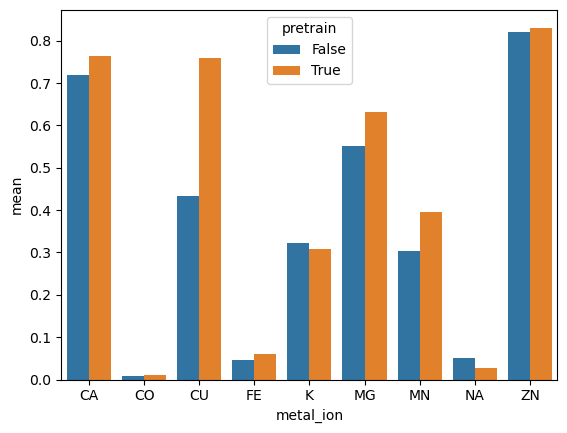

In [16]:
sns_plot = sns.barplot(
    x='metal_ion', 
    y='mean', 
    hue='pretrain', 
    data=mean_auprc, 
)


In [3]:
with open("/n/holylfs06/LABS/mzitnik_lab/Lab/afang/protein_universe/foldseek_cluster/processed2/is_dark_90_plddt_PeSTo_80_ion.pkl", "rb") as f:
    dark_proteome_ion = pickle.load(f)
len(dark_proteome_ion)

2851

In [6]:
AF3_metal_ions = ['MG', 'ZN', 'CA', 'MN', 'FE', 'NA', 'CO', 'CU', 'K']
dark_proteome_predictions = {}
for metal_ion in AF3_metal_ions:
    model_dir = f"/n/netscratch/mzitnik_lab/Lab/afang/InteractNN/models/binary_classifier/{metal_ion}"
    version = sorted(os.listdir(model_dir))[-1]
    topk_file = f"{model_dir}/{version}/checkpoint/topk_map.txt"
    with open(topk_file, 'r') as f:
        topk_map = f.readlines()
    best_ckpt = topk_map[0].split()[1]

    pion_model = torch.load(best_ckpt, map_location='cuda')
    batch_size = 16
    
    predicted_ions = []
    for i in range(0, len(dark_proteome_ion), batch_size):
        end = min(i+batch_size, len(dark_proteome_ion))
        batch = PDBDataset.collate_fn([dark_proteome_ion[j]['data'] for j in range(i, end)])
        batch = Trainer.to_device(batch, 'cuda')
        output = pion_model.infer(batch).detach().cpu()
        predicted_ions.append(output)
    predicted_ions = torch.cat(predicted_ions, dim=0).squeeze()
    dark_proteome_predictions[metal_ion] = predicted_ions
    print(f"{metal_ion} done")

MG done
ZN done
CA done
MN done
FE done
NA done
CO done
CU done
K done


In [ ]:
dark_proteome_ion_ids = [x['id'] for x in dark_proteome_ion]
dark_proteome_predictions_ids = {}
for ion in AF3_metal_ions:
    dark_proteome_predictions_ids[ion] = []
    for i, pred in enumerate(dark_proteome_predictions[ion]):
        if pred > 0.5:
            dark_proteome_predictions_ids[ion].append(dark_proteome_ion_ids[i])
    print(ion, len(dark_proteome_predictions_ids[ion]), len(dark_proteome_ion))

MG 417 2851
ZN 1894 2851
CA 322 2851
MN 34 2851
FE 410 2851
NA 3 2851
CO 62 2851
CU 132 2851
K 1 2851


In [29]:
parameter_tuned_versions = {
    "CA": "/n/netscratch/mzitnik_lab/Lab/afang/InteractNN/models/Pion_tune/version_305/",
    "CO": "/n/netscratch/mzitnik_lab/Lab/afang/InteractNN/models/Pion_tune/version_304/",
    "CU": "/n/netscratch/mzitnik_lab/Lab/afang/InteractNN/models/Pion_tune/version_317/",
    "FE": "/n/netscratch/mzitnik_lab/Lab/afang/InteractNN/models/Pion_tune/version_314/",
    "K": "/n/netscratch/mzitnik_lab/Lab/afang/InteractNN/models/Pion_tune/version_206/",
    "MG": "/n/netscratch/mzitnik_lab/Lab/afang/InteractNN/models/Pion_tune/version_268/",
    "MN": "/n/netscratch/mzitnik_lab/Lab/afang/InteractNN/models/Pion_tune/version_316/",
    "NA": "/n/netscratch/mzitnik_lab/Lab/afang/InteractNN/models/Pion_tune/version_203/",
    "ZN": "/n/netscratch/mzitnik_lab/Lab/afang/InteractNN/models/Pion_tune/version_209/",
}
dark_proteome_predictions = {}

for metal_ion, version in parameter_tuned_versions.items():
    topk_file = f"{version}/checkpoint/topk_map.txt"
    with open(topk_file, 'r') as f:
        topk_map = f.readlines()
    best_ckpt = topk_map[0].split()[1]
    dataset_path = f"/n/netscratch/mzitnik_lab/Lab/afang/InteractNN/protein_universe/protein_interface/Pion/{metal_ion}/{metal_ion}_sequence_30_test.pkl"

    pion_model = torch.load(best_ckpt, map_location='cuda')
    batch_size = 16
    
    predicted_ions = []
    for i in range(0, len(dark_proteome_ion), batch_size):
        end = min(i+batch_size, len(dark_proteome_ion))
        batch = PDBDataset.collate_fn([dark_proteome_ion[j]['data'] for j in range(i, end)])
        batch = Trainer.to_device(batch, 'cuda')
        output = pion_model.infer(batch).detach().cpu()
        predicted_ions.append(output)
    predicted_ions = torch.cat(predicted_ions, dim=0).squeeze()
    dark_proteome_predictions[metal_ion] = predicted_ions
    print(f"{metal_ion} done")

CA done
CO done
CU done
FE done
K done
MG done
MN done
NA done
ZN done


MG 475 2851
ZN 1733 2851
CA 309 2851
MN 51 2851
FE 116 2851
NA 0 2851
CO 13 2851
CU 34 2851
K 0 2851


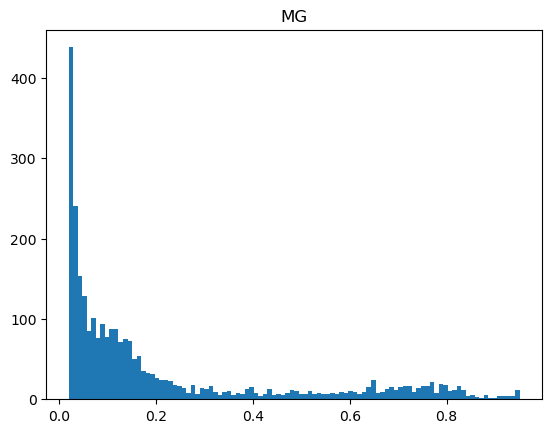

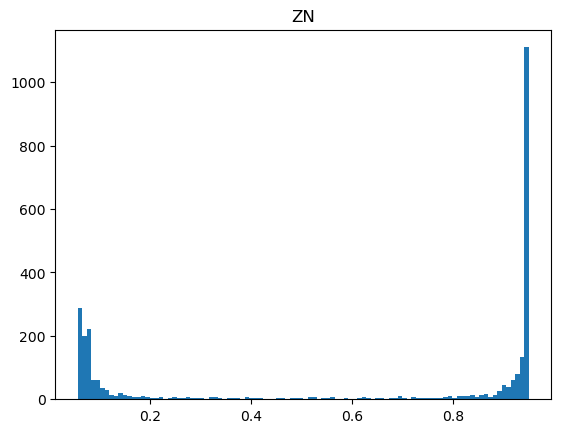

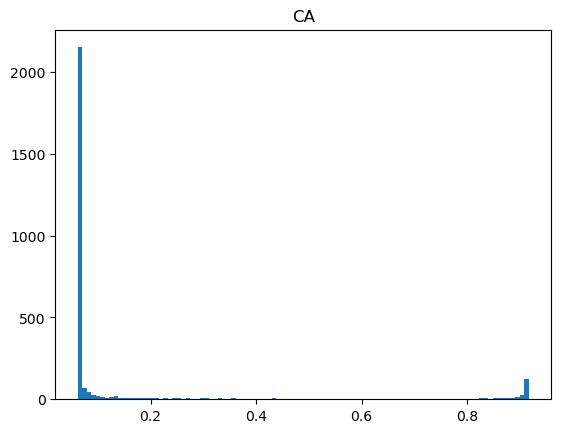

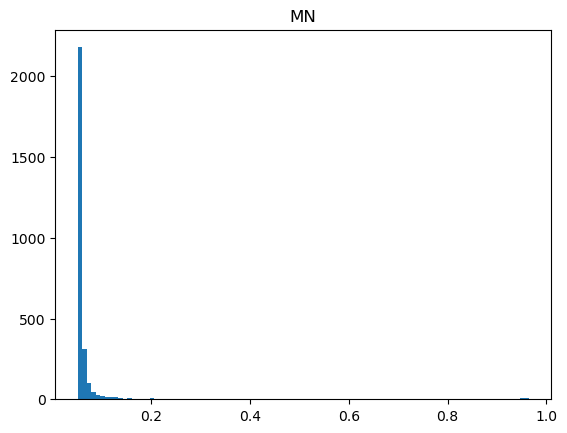

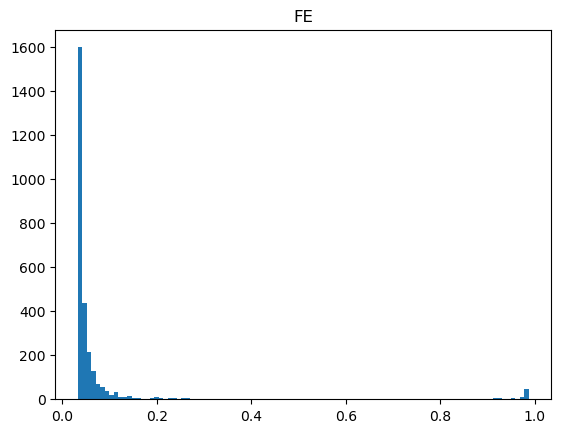

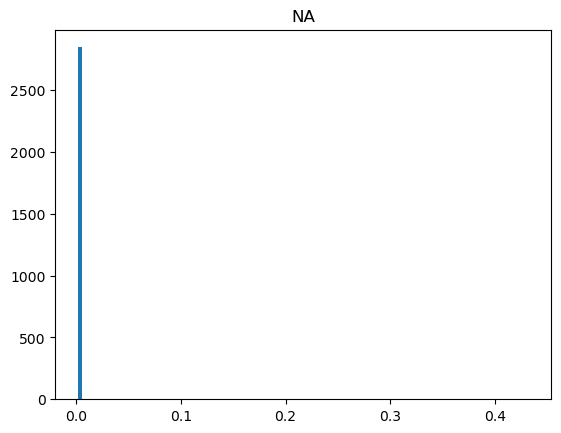

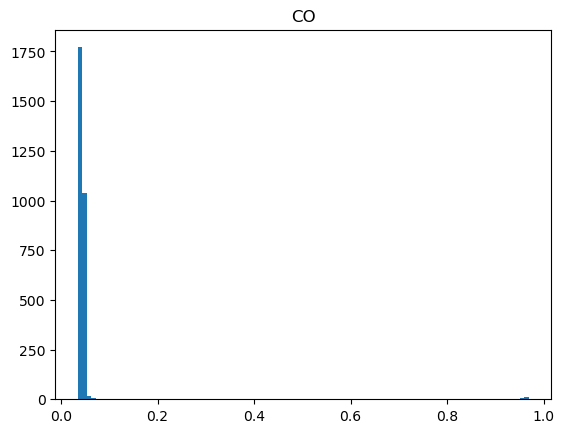

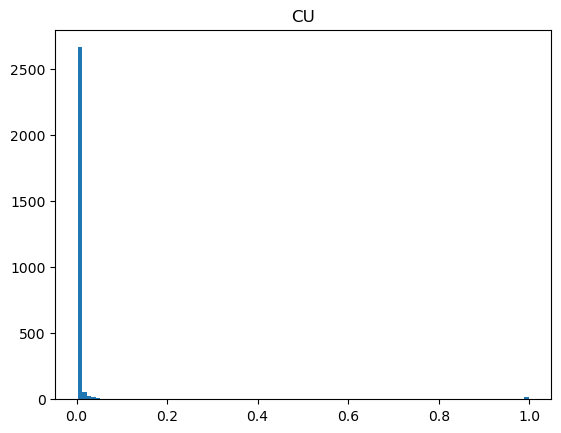

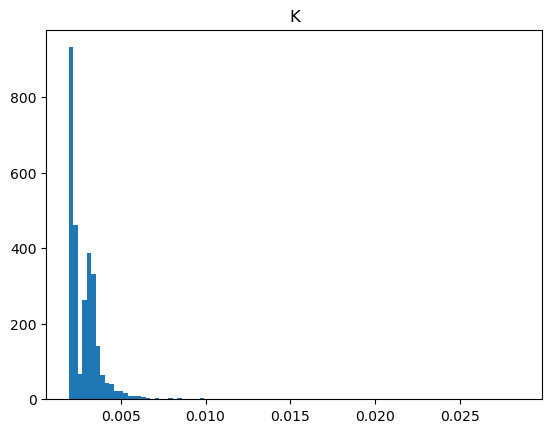

In [30]:
dark_proteome_ion_ids = [x['id'] for x in dark_proteome_ion]
dark_proteome_predictions_ids = {}
AF3_metal_ions = ['MG', 'ZN', 'CA', 'MN', 'FE', 'NA', 'CO', 'CU', 'K']
for ion in AF3_metal_ions:
    dark_proteome_predictions_ids[ion] = []
    for i, pred in enumerate(dark_proteome_predictions[ion]):
        if pred > 0.5:
            dark_proteome_predictions_ids[ion].append(dark_proteome_ion_ids[i])
    print(ion, len(dark_proteome_predictions_ids[ion]), len(dark_proteome_ion))

for ion in AF3_metal_ions:
    plt.hist(dark_proteome_predictions[ion].numpy(), bins=100)
    plt.title(ion)
    plt.show()

In [41]:
query_results_df = pd.read_csv("../protein_universe/retrieved_embeddings/Pion_query_results_cosine_k10.csv")
id_to_fasta = dict(zip(query_results_df['query_id'], query_results_df['query_fasta']))

all_ids = [x['id'] for x in dark_proteome_ion]
for id in tqdm(all_ids, total=len(all_ids)):
    if id not in id_to_fasta:
        new_fasta = pdb_to_fasta(f"/n/holylfs06/LABS/mzitnik_lab/Lab/afang/protein_universe/foldseek_cluster/is_dark_90_plddt/AF-{id}-F1-model_v4.pdb")
        id_to_fasta[id] = new_fasta[f'AF-{id}-F1-model_v4_A']

100%|██████████| 2851/2851 [00:50<00:00, 56.09it/s]


In [ ]:
import pandas as pd
import json
import random
random.seed(42)


for ion in AF3_metal_ions:
    out_dir = f"/n/netscratch/mzitnik_lab/Lab/afang/AF3-output/MLP_1_vs_other_{ion}_v2/"
    os.makedirs(f"{out_dir}/outputs/model", exist_ok=True)
    os.makedirs(f"{out_dir}/outputs/reference", exist_ok=True)

    num_jobs = len(dark_proteome_predictions_ids[ion])
    if num_jobs == 0:
        continue
    num_chunks = max(num_jobs//100, 1)
    chunk_size = num_jobs//num_chunks
    chunks = range(0, num_jobs+chunk_size, chunk_size)
    chunks = list(zip(chunks[:-1], chunks[1:]))
    chunks[-1] = (chunks[-1][0], num_jobs)

    dark_proteome_ion_ids = [x['id'] for x in dark_proteome_ion]
    random.shuffle(dark_proteome_ion_ids)
    random_jobs = dark_proteome_ion_ids[:num_jobs]

    # write AF3 format
    jobs = []
    for chunk_i, (start, end) in enumerate(chunks):
        os.makedirs(f"{out_dir}/inputs/model{chunk_i}", exist_ok=True)
        os.makedirs(f"{out_dir}/inputs/reference{chunk_i}", exist_ok=True)
        for idx in range(start, end):
            item_id = dark_proteome_predictions_ids[ion][idx]
            item_job1 = {
                "name": item_id + '_model',
                "modelSeeds": [1],
                "sequences": [
                    {"protein": {"id": 'A', "sequence": id_to_fasta[item_id]}},
                    {"ligand": {"id": ['B'], "ccdCodes": [ion]}},
                ],
                "dialect": "alphafold3",
                "version": 1
            }

            random_id = random_jobs[idx]
            item_job2 = {
                "name": random_id + '_reference',
                "modelSeeds": [1],
                "sequences": [
                    {"protein": {"id": 'A', "sequence": id_to_fasta[random_id]}},
                    {"ligand": {"id": ['B'], "ccdCodes": [ion]}},
                ],
                "dialect": "alphafold3",
                "version": 1
            }
            with open(f'{out_dir}/inputs/model{chunk_i}/{item_id}_model.json', 'w') as f:
                json.dump(item_job1, f, indent=2)
            with open(f'{out_dir}/inputs/reference{chunk_i}/{random_id}_reference.json', 'w') as f:
                json.dump(item_job2, f, indent=2)

## Analyse AF3 outputs

In [3]:
import os
from glob import glob

AF3_metal_ions = ['MG', 'ZN', 'CA', 'MN', 'FE', 'NA', 'CO', 'CU', 'K']
for ion in AF3_metal_ions:
    print(ion)
    model_output_dir = f"/n/netscratch/mzitnik_lab/Lab/afang/AF3-output/MLP_1_vs_other_{ion}_v2/outputs/model"
    model_processed_items = os.listdir(model_output_dir)
    reference_output_dir = f"/n/netscratch/mzitnik_lab/Lab/afang/AF3-output/MLP_1_vs_other_{ion}_v2/outputs/reference"
    reference_processed_items = os.listdir(reference_output_dir)

    all_reference = glob(f"/n/netscratch/mzitnik_lab/Lab/afang/AF3-output/MLP_1_vs_other_{ion}_v2/inputs/reference*/*.json")
    all_reference = [os.path.basename(x).replace('.json', '').lower() for x in all_reference]
    print(f"missing reference {len(set(all_reference) - set(reference_processed_items))} out of {len(set(all_reference))}, {len(all_reference)}")

    all_model = glob(f"/n/netscratch/mzitnik_lab/Lab/afang/AF3-output/MLP_1_vs_other_{ion}_v2/inputs/model*/*.json")
    all_model = [os.path.basename(x).replace('.json', '').lower() for x in all_model]
    print(f"missing model {len(set(all_model) - set(model_processed_items))} out of {len(set(all_model))}, {len(all_model)}")

MG
missing reference 0 out of 475, 475
missing model 0 out of 475, 475
ZN
missing reference 0 out of 1733, 1733
missing model 0 out of 1733, 1733
CA
missing reference 0 out of 309, 309
missing model 0 out of 309, 309
MN
missing reference 0 out of 51, 51
missing model 0 out of 51, 51
FE
missing reference 0 out of 116, 116
missing model 0 out of 116, 116
NA
missing reference 0 out of 0, 0
missing model 0 out of 0, 0
CO
missing reference 0 out of 13, 13
missing model 0 out of 13, 13
CU
missing reference 34 out of 34, 34
missing model 34 out of 34, 34
K
missing reference 0 out of 0, 0
missing model 0 out of 0, 0


In [7]:
with open("/n/holylfs06/LABS/mzitnik_lab/Lab/afang/protein_universe/foldseek_cluster/processed2/is_dark_90_plddt_PeSTo_80_ion.pkl", "rb") as f:
    dark_proteome_ion = pickle.load(f)
dark_proteome_ion_ids = [x['id'] for x in dark_proteome_ion]
len(dark_proteome_ion)

2851

Modeled uniprots 2410 out of 2851


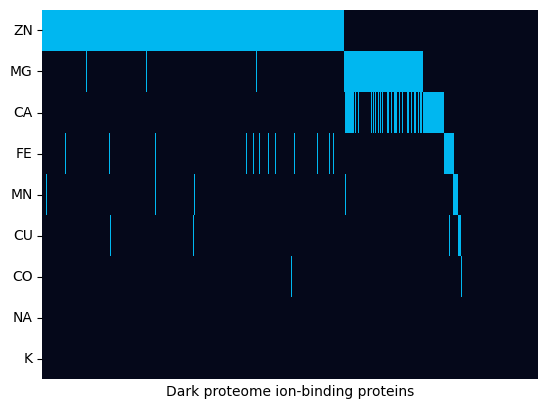

In [8]:
AF3_metal_ions = ['ZN', 'MG', 'CA', 'FE', 'MN', 'CU', 'CO', 'NA', 'K']
heatmap = np.zeros((len(AF3_metal_ions), len(dark_proteome_ion)))
dark_proteome_ion_ids_ordered = []
for ion_idx, ion in enumerate(AF3_metal_ions):
    all_model = glob(f"/n/netscratch/mzitnik_lab/Lab/afang/AF3-output/MLP_1_vs_other_{ion}_v2/inputs/model*/*.json")
    for model in all_model:
        uniprot_id = os.path.basename(model).replace('_model.json', '')
        if uniprot_id not in dark_proteome_ion_ids_ordered:
            dark_proteome_ion_ids_ordered.append(uniprot_id)
        idx = dark_proteome_ion_ids_ordered.index(uniprot_id)
        heatmap[ion_idx, idx] = 1
modeled_uniprots = sum(heatmap.sum(axis=0) > 0)
print(f"Modeled uniprots {modeled_uniprots} out of {len(dark_proteome_ion_ids)}")

from matplotlib.colors import ListedColormap
cmap = ListedColormap(["#05081A", '#00b7f0'])

ax = sns.heatmap(heatmap, cbar=False, cmap=cmap)
ax.set_yticklabels(AF3_metal_ions)
plt.yticks(rotation=0)

ax.set_xticks([])
ax.set_xticklabels([])
ax.set_xlabel("Dark proteome ion-binding proteins")
plt.show()


In [1]:
# analyse AF3 output
from glob import glob
import json
import os
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

AF3_metal_ions = ['MG', 'ZN', 'CA', 'MN', 'FE', 'NA', 'CO', 'CU', 'K']
results_df = []
for ion in AF3_metal_ions:
    if not os.path.exists(f"/n/netscratch/mzitnik_lab/Lab/afang/AF3-output/MLP_1_vs_other_{ion}_v2/"):
        continue
    model_outputs = glob(f"/n/netscratch/mzitnik_lab/Lab/afang/AF3-output/MLP_1_vs_other_{ion}_v2/outputs/model/**/*summary_confidences.json")
    reference_outputs = glob(f"/n/netscratch/mzitnik_lab/Lab/afang/AF3-output/MLP_1_vs_other_{ion}_v2/outputs/reference/**/*_summary_confidences.json")

    for fname in model_outputs:
        with open(fname, 'r') as f:
            data = json.load(f)
        id_name = os.path.basename(fname).replace("_summary_confidences.json", "")
        iptm = data['iptm']
        ptm = data['ptm']
        with open(fname.replace("_summary_confidences.json", "_data.json"), 'r') as f:
            data = json.load(f)
        if 'ccdCodes' in data['sequences'][1]['ligand']:
            ligand = data['sequences'][1]['ligand']['ccdCodes'][0]
        else:
            ligand = data['sequences'][1]['ligand']['smiles']
            if ligand == 'CC=C1C(=C2C=C3C(=CC)C(=C4N3[Fe]56N2C1=Cc7n5c(c(c7C)CCC(=O)O)C=C8N6C(=C4)C(=C8CCC(=O)O)C)C)C':
                ligand = 'HEC'
        results_df.append({"ligand": ligand, "id": id_name.split("_")[0], "type": id_name.split("_")[1], "iptm": iptm, "ptm": ptm, "ion": ion})
    for fname in reference_outputs:
        with open(fname, 'r') as f:
            data = json.load(f)
        id_name = os.path.basename(fname).replace("_summary_confidences.json", "")
        iptm = data['iptm']
        ptm = data['ptm']
        with open(fname.replace("_summary_confidences.json", "_data.json"), 'r') as f:
            data = json.load(f)
        if 'ccdCodes' in data['sequences'][1]['ligand']:
            ligand = data['sequences'][1]['ligand']['ccdCodes'][0]
        else:
            ligand = data['sequences'][1]['ligand']['smiles']
            if ligand == 'CC=C1C(=C2C=C3C(=CC)C(=C4N3[Fe]56N2C1=Cc7n5c(c(c7C)CCC(=O)O)C=C8N6C(=C4)C(=C8CCC(=O)O)C)C)C':
                ligand = 'HEC'
        results_df.append({"ligand": ligand, "id": id_name.split("_")[0], "type": id_name.split("_")[1], "iptm": iptm, "ptm": ptm, "ion": ion})

results_df = pd.DataFrame(results_df)

In [2]:
results_df.to_csv('/n/holylfs06/LABS/mzitnik_lab/Lab/afang/protein_universe/foldseek_cluster/AF3_outputs/Pion_AF3_scores.csv', index=False)
results_df[results_df.type == 'model'][['ligand', 'id', 'iptm', 'ptm']].to_csv('/n/holylfs06/LABS/mzitnik_lab/Lab/afang/protein_universe/foldseek_cluster/AF3_outputs/Pion_AF3_model_scores.csv', index=False)

In [10]:
from scipy.stats import ks_2samp
model_data = results_df[results_df['type'] == 'model']['iptm']
reference_data = results_df[results_df['type'] == 'reference']['iptm']
ks_statistic, p_value = ks_2samp(model_data, reference_data)

print(f"iPTM KS Statistic: {ks_statistic}")
print(f"iPTM P-value: {p_value}")

model_data = results_df[results_df['type'] == 'model']['ptm']
reference_data = results_df[results_df['type'] == 'reference']['ptm']
ks_statistic, p_value = ks_2samp(model_data, reference_data)

print(f"PTM KS Statistic: {ks_statistic}")
print(f"PTM P-value: {p_value}")

iPTM KS Statistic: 0.1171672228401928
iPTM P-value: 1.5394028315672344e-16
PTM KS Statistic: 0.025583982202447165
PTM P-value: 0.34060653321940454


In [11]:
foldseek_cluster = pd.read_csv("/n/holylfs06/LABS/mzitnik_lab/Lab/afang/protein_universe/2-repId_isDark_nMem_repLen_avgLen_repPlddt_avgPlddt_LCAtaxId.tsv", sep="\t",
                                names= ["repID", "isDark", "nMem", "repLen", "avgLen", "repPlddt", "avgPlddt", "LCAtaxID"])
results_df['id'] = results_df['id'].apply(lambda x: x.upper())
results_df = results_df.merge(foldseek_cluster, left_on='id', right_on='repID', how='left')
results_df

,ligand,id,type,iptm,ptm,ion,repID,isDark,nMem,repLen,avgLen,repPlddt,avgPlddt,LCAtaxID
0,MG,A0A011WN45,model,0.91,0.91,MG,A0A011WN45,1,2,454,452.000,88.88,91.6600,1263
1,MG,A0A031LL90,model,0.86,0.90,MG,A0A031LL90,1,11,145,145.909,91.19,90.6191,2281
2,MG,A0A076H8N7,model,0.90,0.91,MG,A0A076H8N7,1,3,225,217.333,93.94,94.4367,2626047
3,MG,A0A085BA52,model,0.83,0.84,MG,A0A085BA52,1,5,92,87.600,90.75,93.9620,976
4,MG,A0A090QNW6,model,0.73,0.71,MG,A0A090QNW6,1,8,134,147.125,85.56,90.2425,976
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5389,CO,A0A7G9S0A0,reference,0.93,0.92,CO,A0A7G9S0A0,1,13,262,268.615,88.88,92.6992,526524
5390,CO,A0A7H5F1S7,reference,0.66,0.82,CO,A0A7H5F1S7,1,4,70,70.000,91.25,90.0950,2
5391,CO,A0A7L6B4Q7,reference,0.98,0.68,CO,A0A7L6B4Q7,1,7,260,261.857,93.19,90.7229,131567
5392,CO,A0A842ULW8,reference,0.96,0.92,CO,A0A842ULW8,1,2,107,108.000,90.25,93.2200,131567


In [82]:
cluster_assignments = pd.read_csv('/n/holylfs06/LABS/mzitnik_lab/Lab/afang/protein_universe/1-AFDBClusters-entryId_repId_taxId_with_taxName.tsv.gz', compression='gzip', sep='\t')
cluster_ancestors = cluster_assignments[cluster_assignments['repId'].isin(results_df['repID'][results_df['type'] == 'model'])].groupby('repId').agg({'Ancestor': Counter}).reset_index()
cluster_ancestors['num_ancestors'] = cluster_ancestors['Ancestor'].apply(lambda x: len(set(x.keys()).intersection(set([' Bacteria', ' Archaea', ' Eukaryota']))))
cluster_ancestors.sort_values(by='num_ancestors', ascending=False, inplace=True)
cluster_ancestors

,repId,Ancestor,num_ancestors
2368,W2EKU0,"{' Bacteria': 29, ' Eukaryota': 10, ' Archaea'...",3
926,A0A327SAS6,"{' Bacteria': 24, ' Archaea': 1, ' unclassifie...",3
1213,A0A496MS18,"{' Bacteria': 144, ' unclassified sequences': ...",3
1423,A0A552UZ29,"{' Bacteria': 19, ' Eukaryota': 1, ' Archaea': 1}",3
156,A0A0Q8TPY4,"{' Bacteria': 32, ' Eukaryota': 1, ' unclassif...",3
...,...,...,...
77,A0A0F9K2A7,{' unclassified sequences': 3},0
78,A0A0F9K6U8,{' unclassified sequences': 2},0
80,A0A0F9L0I5,{' unclassified sequences': 2},0
85,A0A0F9PC72,{' unclassified sequences': 2},0


In [87]:
results_df_with_ancestors = results_df.merge(cluster_ancestors, left_on='repID', right_on='repId', how='left')
results_df_with_ancestors[(results_df_with_ancestors['num_ancestors'] == 3) & (results_df_with_ancestors['type'] == 'model')].sort_values(by='nMem', ascending=False)

,ligand,id,type,iptm,ptm,ion,repID,isDark,nMem,repLen,avgLen,repPlddt,avgPlddt,LCAtaxID,repId,Ancestor,num_ancestors
4573,CA,A0A496MS18,model,0.96,0.88,CA,A0A496MS18,1,169,186,184.284,91.69,92.5182,131567,A0A496MS18,"{' Bacteria': 144, ' unclassified sequences': ...",3.0
438,MG,D3BAP7,model,0.79,0.83,MG,D3BAP7,1,155,215,223.897,92.25,90.8877,131567,D3BAP7,"{' Bacteria': 131, ' Eukaryota': 10, ' unclass...",3.0
1653,ZN,A0A352V9P3,model,0.97,0.87,ZN,A0A352V9P3,1,76,130,130.316,90.06,91.9533,131567,A0A352V9P3,"{' Bacteria': 65, ' Eukaryota': 4, ' unclassif...",3.0
468,MG,W2EKU0,model,0.95,0.82,MG,W2EKU0,1,44,204,197.864,91.31,90.6202,131567,W2EKU0,"{' Bacteria': 29, ' Eukaryota': 10, ' Archaea'...",3.0
4723,CA,W2EKU0,model,0.97,0.77,CA,W2EKU0,1,44,204,197.864,91.31,90.6202,131567,W2EKU0,"{' Bacteria': 29, ' Eukaryota': 10, ' Archaea'...",3.0
1072,ZN,A0A0Q8TPY4,model,0.97,0.87,ZN,A0A0Q8TPY4,1,35,194,205.800,94.25,92.5937,131567,A0A0Q8TPY4,"{' Bacteria': 32, ' Eukaryota': 1, ' unclassif...",3.0
1630,ZN,A0A327SAS6,model,0.96,0.88,ZN,A0A327SAS6,1,27,151,154.037,88.12,90.3519,131567,A0A327SAS6,"{' Bacteria': 24, ' Archaea': 1, ' unclassifie...",3.0
1999,ZN,A0A552UZ29,model,0.95,0.90,ZN,A0A552UZ29,1,21,173,166.048,95.69,94.6138,131567,A0A552UZ29,"{' Bacteria': 19, ' Eukaryota': 1, ' Archaea': 1}",3.0
4462,CA,A0A1Q6KAJ7,model,0.81,0.82,CA,A0A1Q6KAJ7,1,11,111,113.364,93.38,91.1709,131567,A0A1Q6KAJ7,"{' Eukaryota': 1, ' Bacteria': 9, ' Archaea': 1}",3.0
436,MG,C5KVD0,model,0.96,0.81,MG,C5KVD0,1,10,269,268.500,85.88,90.7870,131567,C5KVD0,"{' Bacteria': 8, ' Archaea': 1, ' Eukaryota': 1}",3.0


to check out further: A0A496MS18-CA, A0A352V9P3-ZN, W2EKU0-MG/CA, A0A0Q8TPY4-ZN, A0A552UZ29-ZN

In [91]:
"A0A552UZ29".lower()

'a0a552uz29'

In [67]:
results_df[results_df['type'] == 'model'].sort_values("nMem", ascending=False).head(20)

,ligand,id,type,iptm,ptm,ion,repID,isDark,nMem,repLen,avgLen,repPlddt,avgPlddt,LCAtaxID
2576,ZN,G8QUB4,model,0.93,0.86,ZN,G8QUB4,1,189,68,68.8360,96.88,92.9828,2
1400,ZN,A0A2A4SRG2,model,0.42,0.63,ZN,A0A2A4SRG2,1,171,214,233.1290,38.50,90.6154,131567
4573,CA,A0A496MS18,model,0.96,0.88,CA,A0A496MS18,1,169,186,184.2840,91.69,92.5182,131567
1917,ZN,A0A4V2YNK2,model,0.97,0.89,ZN,A0A4V2YNK2,1,160,208,206.4380,95.00,94.5021,2
438,MG,D3BAP7,model,0.79,0.83,MG,D3BAP7,1,155,215,223.8970,92.25,90.8877,131567
2499,ZN,A0A849WBS1,model,0.94,0.86,ZN,A0A849WBS1,1,131,156,154.8780,92.25,90.9999,131567
1957,ZN,A0A523PPL3,model,0.90,0.78,ZN,A0A523PPL3,1,130,337,331.6770,87.69,90.2641,131567
2623,ZN,R5CIV4,model,0.93,0.72,ZN,R5CIV4,1,117,107,109.4270,88.25,92.4634,2
121,MG,A0A2D8XYM8,model,0.79,0.83,MG,A0A2D8XYM8,1,116,226,231.7070,40.94,91.1038,131567
2487,ZN,A0A846WX37,model,0.97,0.85,ZN,A0A846WX37,1,112,170,184.6520,61.22,91.3199,2


In [5]:
results_df.groupby(['ion', 'type'])[['iptm', 'ptm']].agg(['mean', 'std'])

iptm                 ptm          
                   mean       std      mean       std
ion type                                             
CA  model      0.846472  0.123961  0.766699  0.137831
    reference  0.833463  0.111559  0.792265  0.118511
CO  model      0.938462  0.034362  0.848462  0.047054
    reference  0.903077  0.082197  0.793846  0.154733
FE  model      0.936379  0.049103  0.857672  0.078246
    reference  0.887477  0.099651  0.794019  0.115251
MG  model      0.803726  0.139244  0.792589  0.131498
    reference  0.804253  0.127052  0.793895  0.126504
MN  model      0.888235  0.129270  0.803333  0.130792
    reference  0.882745  0.089802  0.774314  0.147638
ZN  model      0.917640  0.073192  0.761056  0.133309
    reference  0.893370  0.098206  0.769810  0.132023

/n/home13/afang/.conda/envs/interactenv1/lib/python3.9/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/n/home13/afang/.conda/envs/interactenv1/lib/python3.9/site-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/n/home13/afang/.conda/envs/interactenv1/lib/python3.9/site-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/n/home13/afang/.conda/envs/in

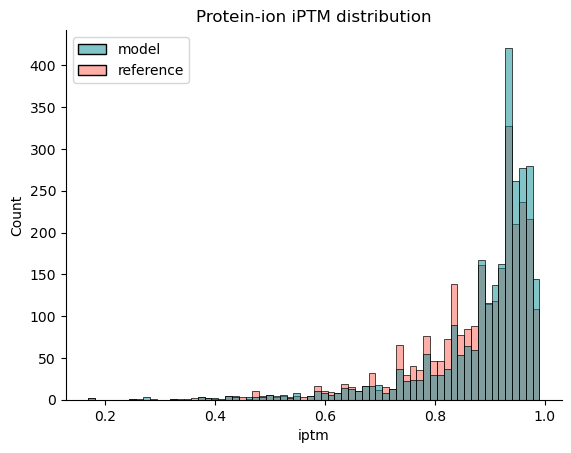

/n/home13/afang/.conda/envs/interactenv1/lib/python3.9/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/n/home13/afang/.conda/envs/interactenv1/lib/python3.9/site-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/n/home13/afang/.conda/envs/interactenv1/lib/python3.9/site-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/n/home13/afang/.conda/envs/in

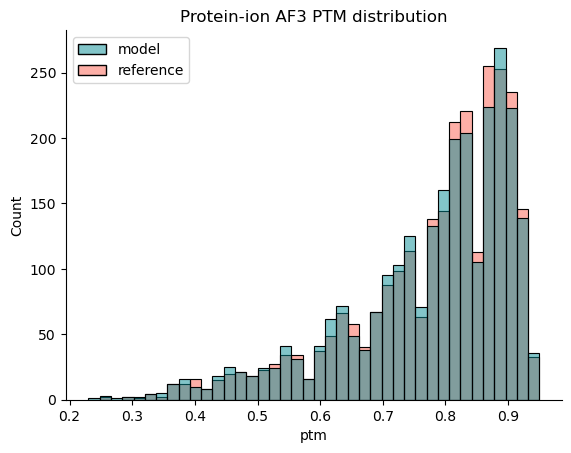

In [12]:
custom_colors = ['#7B2EF7', '#26CFC0', '#E65AFA', '#078C95', '#506DFF', '#FC6151', '#FC51A1', '#5AFFAE', '#FCE351', '#C89CFF', '#FC51BF', '#ADDEFF']

sns.histplot(data=results_df, x='iptm', hue='type', common_norm=False,  palette=[custom_colors[3], custom_colors[5]])
plt.title(f"Protein-ion iPTM distribution")
plt.gca().get_legend().set_title('')
sns.despine()
plt.show()

sns.histplot(data=results_df, x='ptm', hue='type', common_norm=False, palette=[custom_colors[3], custom_colors[5]])
plt.title(f"Protein-ion AF3 PTM distribution")
plt.gca().get_legend().set_title('')
sns.despine()
plt.show()

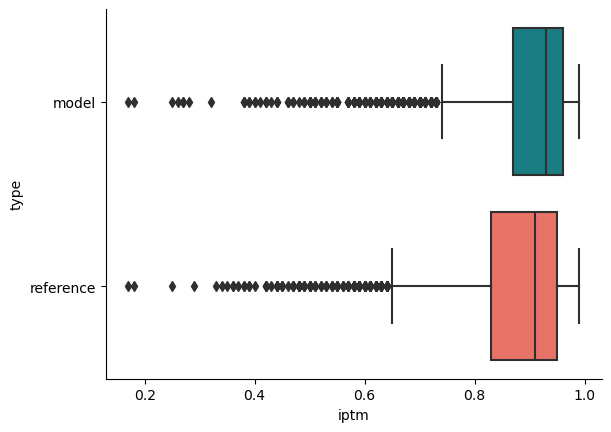

In [31]:
sns.boxplot(data=results_df, x='iptm', y='type', palette=[custom_colors[3], custom_colors[5]])
sns.despine()

In [25]:
sum(results_df[results_df['type'] == 'model']['iptm'] > 0.8)/len(results_df[results_df['type'] == 'model']), sum(results_df[results_df['type'] == 'reference']['iptm'] > 0.8)/len(results_df[results_df['type'] == 'model'])

(0.8527994067482387, 0.7994067482387839)

In [24]:
results_df[results_df['type'] == 'model']['iptm'].median(), results_df[results_df['type'] == 'reference']['iptm'].median()

(0.93, 0.91)

In [28]:
results_df[results_df['type'] == 'model']['iptm'].quantile(0.25), results_df[results_df['type'] == 'reference']['iptm'].quantile(0.25)

(0.87, 0.83)

In [18]:
results_df[results_df['type'] == 'reference']['iptm'].mean()

0.8705376344086022

/n/home13/afang/.conda/envs/interactenv1/lib/python3.9/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/n/home13/afang/.conda/envs/interactenv1/lib/python3.9/site-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/n/home13/afang/.conda/envs/interactenv1/lib/python3.9/site-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/n/home13/afang/.conda/envs/in

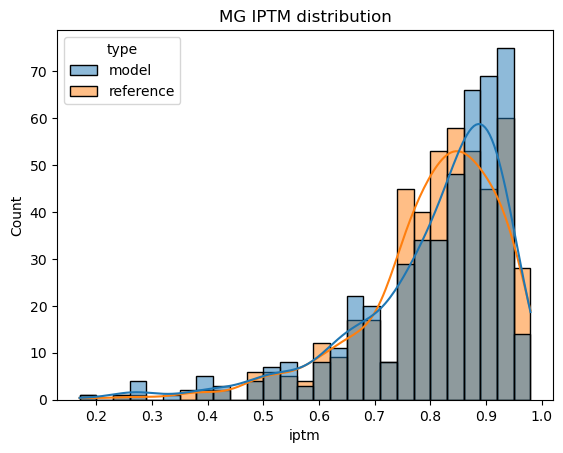

/n/home13/afang/.conda/envs/interactenv1/lib/python3.9/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/n/home13/afang/.conda/envs/interactenv1/lib/python3.9/site-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/n/home13/afang/.conda/envs/interactenv1/lib/python3.9/site-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/n/home13/afang/.conda/envs/in

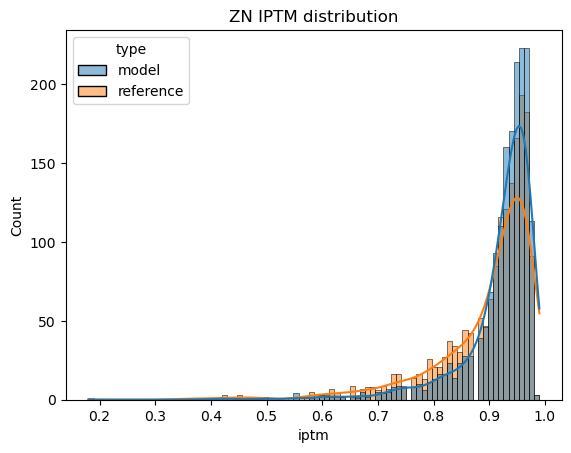

/n/home13/afang/.conda/envs/interactenv1/lib/python3.9/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/n/home13/afang/.conda/envs/interactenv1/lib/python3.9/site-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/n/home13/afang/.conda/envs/interactenv1/lib/python3.9/site-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/n/home13/afang/.conda/envs/in

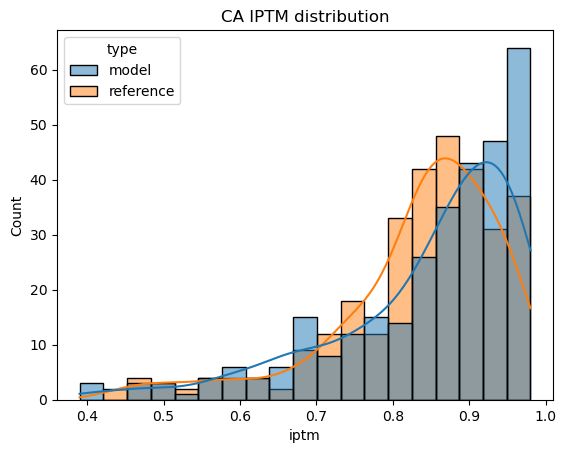

/n/home13/afang/.conda/envs/interactenv1/lib/python3.9/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/n/home13/afang/.conda/envs/interactenv1/lib/python3.9/site-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/n/home13/afang/.conda/envs/interactenv1/lib/python3.9/site-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/n/home13/afang/.conda/envs/in

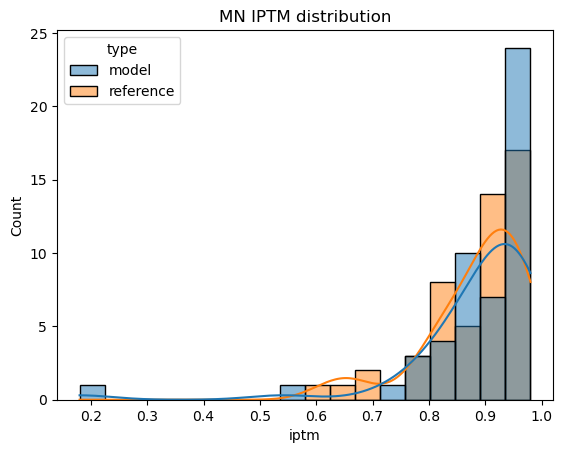

/n/home13/afang/.conda/envs/interactenv1/lib/python3.9/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/n/home13/afang/.conda/envs/interactenv1/lib/python3.9/site-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/n/home13/afang/.conda/envs/interactenv1/lib/python3.9/site-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/n/home13/afang/.conda/envs/in

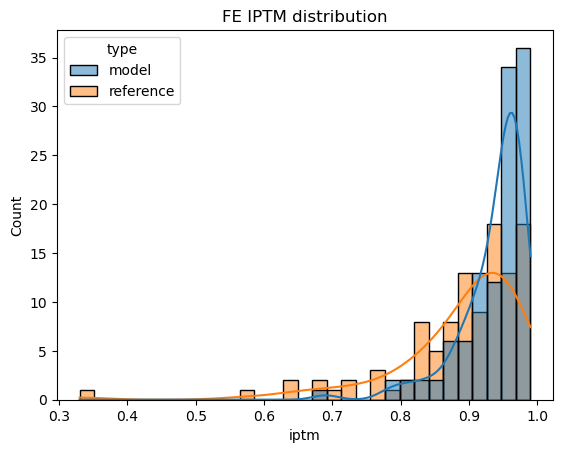

/n/home13/afang/.conda/envs/interactenv1/lib/python3.9/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/n/home13/afang/.conda/envs/interactenv1/lib/python3.9/site-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/n/home13/afang/.conda/envs/interactenv1/lib/python3.9/site-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/n/home13/afang/.conda/envs/in

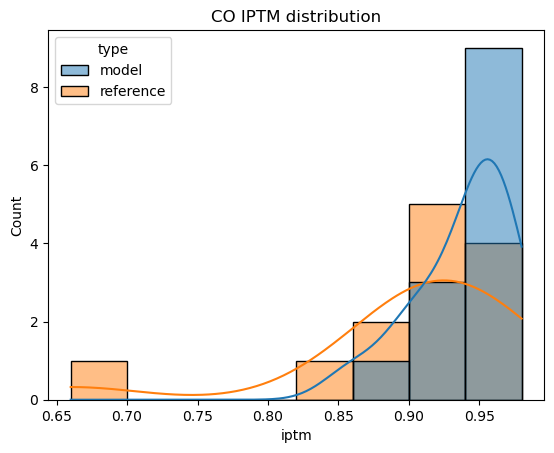

In [6]:
for ion in results_df['ion'].unique():
    sns.histplot(data=results_df[results_df['ion'] == ion], x='iptm', hue='type', kde=True, common_norm=False)
    plt.title(f"{ion} IPTM distribution")
    plt.show()